# Load Packages

In [79]:
# ==============================
# Install required packages
# ==============================
!pip install -q --upgrade pip
!pip install -q pyunpack patool rarfile rioxarray rasterio xarray

# ==============================
# Standard library
# ==============================
import os
import sys
import glob
import pathlib
import zipfile

# ==============================
# General utilities
# ==============================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Image handling
# ==============================
import PIL
from PIL import Image

# ==============================
# Raster / geospatial
# ==============================
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window
import rioxarray as rxr

# ==============================
# Archive handling
# ==============================
import pyunpack
from rarfile import RarFile

# ==============================
# TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    UpSampling2D, Dropout, BatchNormalization,
    Activation, concatenate, add, multiply
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# Evaluation metrics
# ==============================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)


In [80]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
# Specify whether to download data or read in
download = True
base_dir = "./content/Iraq_Marshes_s2_water_seg/"

In [83]:
# Download data
if download:
    url = 'https://zenodo.org/records/18474639/files/Iraq_Marshes_s2_water_seg.zip?download=1'

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
      f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
      z.extractall("/content/")

    # confirm
    os.listdir("/content/")

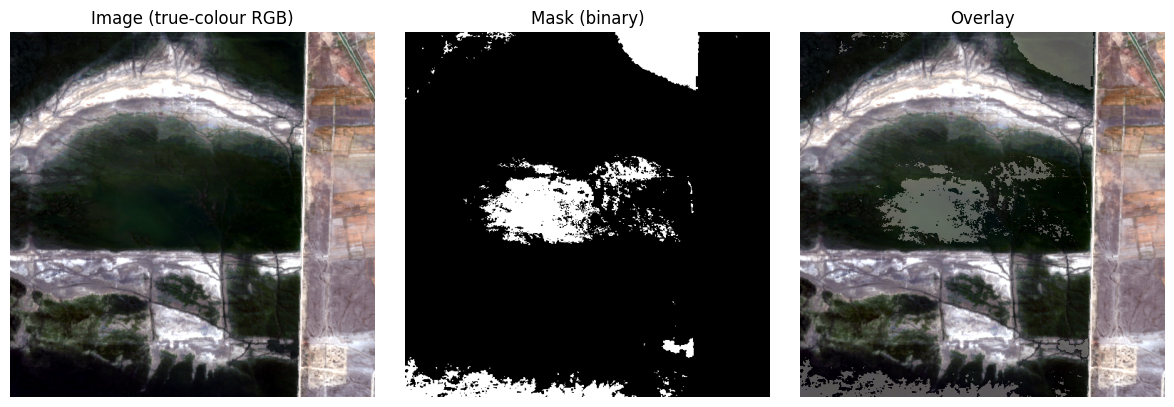

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [84]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg/"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

# Functions

In [85]:
'''
  Returns an image plot of mask prediction
'''

def reconstruct_image(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])
  # Standardise between 0-1
  reconstruction = reconstruction/np.max(reconstruction)

  # Round to 0-1, binary pixel-by-pixel classification
  if rounded:
    reconstruction = np.round(reconstruction)

  # Plot reconstructed mask (prediction)
  plt.imshow(reconstruction)

In [86]:
'''
  Returns array of mask prediction, given model and image
'''
def reconstruct_array(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])

  if rounded:
    reconstruction = np.round(reconstruction)

  return reconstruction # Returns array

In [87]:
'''
  Metric functions for evaluation
'''

def score_eval(model, image, mask): # Gives score of mask vs prediction
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return accuracy_score(mask.flatten(), reconstruction)

  else: # If a list of images input, find accuracy for each
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 3))
      reconstruction = np.round(reconstruction).flatten()

      scores.append(accuracy_score(mask[i].flatten(), reconstruction))

    return scores

def score_eval2(model, image, mask): # Gives score of mask vs prediction
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return accuracy_score(mask.flatten(), reconstruction)

  else: # If a list of images input, find accuracy for each
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 4))
      reconstruction = np.round(reconstruction).flatten()

      scores.append(accuracy_score(mask[i].flatten(), reconstruction))

    return scores

def recall_eval(model, image, mask): # Find recall score
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return recall_score(mask.flatten(), reconstruction, average='weighted')

  else: # If a list of images input, find accuracy for each
    recall = []
    for i in range(len(image)):
        reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
        reconstruction = np.round(reconstruction).flatten()

        recall.append(recall_score(mask[i].flatten(), reconstruction, average='weighted'))

    return recall

def precision_eval(model, image, mask): # Find precision score
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return precision_score(mask.flatten(), reconstruction, average='weighted')

  else: # If a list of images input, find accuracy for each
    precision = []
    for i in range(len(image)):
        reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
        reconstruction = np.round(reconstruction).flatten()

        precision.append(precision_score(mask[i].flatten(), reconstruction, average='weighted'))

    return precision

def f1_score_eval(model, image, mask): # Find F1-score
    prec = np.mean(precision_eval(model, image, mask))
    rec = np.mean(recall_eval(model, image, mask))

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def f1_score_eval_basic(precision, recall):
    prec = np.mean(precision)
    rec = np.mean(recall)

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def produce_mask(image): # Outputs rounded image (binary)
  return np.round(image)

# Ingest and Process RGB Dataset

In [88]:

# ==============================================================================
# INGEST IMAGES
# ==============================================================================

## Training images
training_images_list = os.listdir(f"{base_dir}training/images/")
training_masks_list = []
training_images = []

for n in training_images_list:
    a = np.load(f"{base_dir}training/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    training_images.append(a)
    training_masks_list.append(n)  # Same filename for mask

## Training masks
training_masks = []
for n in training_masks_list:
    a = np.load(f"{base_dir}training/masks/{n}")
    training_masks.append(a)

## Test images
test_images_list = os.listdir(f"{base_dir}test/images/")
test_images = []
for n in test_images_list:
    a = np.load(f"{base_dir}test/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    test_images.append(a)

## Test masks
test_masks_list = []
test_masks = []
for n in test_images_list:
    test_masks_list.append(n)

for n in test_masks_list:
    a = np.load(f"{base_dir}test/masks/{n}")
    test_masks.append(a)

## Validation images
validation_images_list = os.listdir(f"{base_dir}validation/images/")
validation_masks_list = []
validation_images = []

for n in validation_images_list:
    a = np.load(f"{base_dir}validation/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    validation_images.append(a)
    validation_masks_list.append(n)  # Same filename for mask

## Validation masks
validation_masks = []
for n in validation_masks_list:
    a = np.load(f"{base_dir}validation/masks/{n}")
    validation_masks.append(a)

print(f"Loaded:")
print(f"Training: {len(training_images)} images, {len(training_masks)} masks")
print(f"Validation: {len(validation_images)} images, {len(validation_masks)} masks")
print(f"Test: {len(test_images)} images, {len(test_masks)} masks")
print(f"\nShapes:")
print(f"Training image: {training_images[0].shape}")
print(f"Training mask: {training_masks[0].shape}")

Loaded:
Training: 143 images, 143 masks
Validation: 99 images, 99 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 3)
Training mask: (512, 512, 1)



Preprocessing training data...


/tmp/ipython-input-3228717862.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr_uint8, mode="RGB")


Preprocessing validation data...
Preprocessing test data...

PREPROCESSED ARRAYS:
X_train: (143, 512, 512, 3) float32 range: [0.000, 1.000]
Y_train: (143, 512, 512, 1) uint8 unique: [0 1]
X_val  : (99, 512, 512, 3) float32 range: [0.000, 1.000]
Y_val  : (99, 512, 512, 1) uint8 unique: [0 1]
X_test : (20, 512, 512, 3) float32 range: [0.000, 1.000]
Y_test : (20, 512, 512, 1) uint8 unique: [0 1]


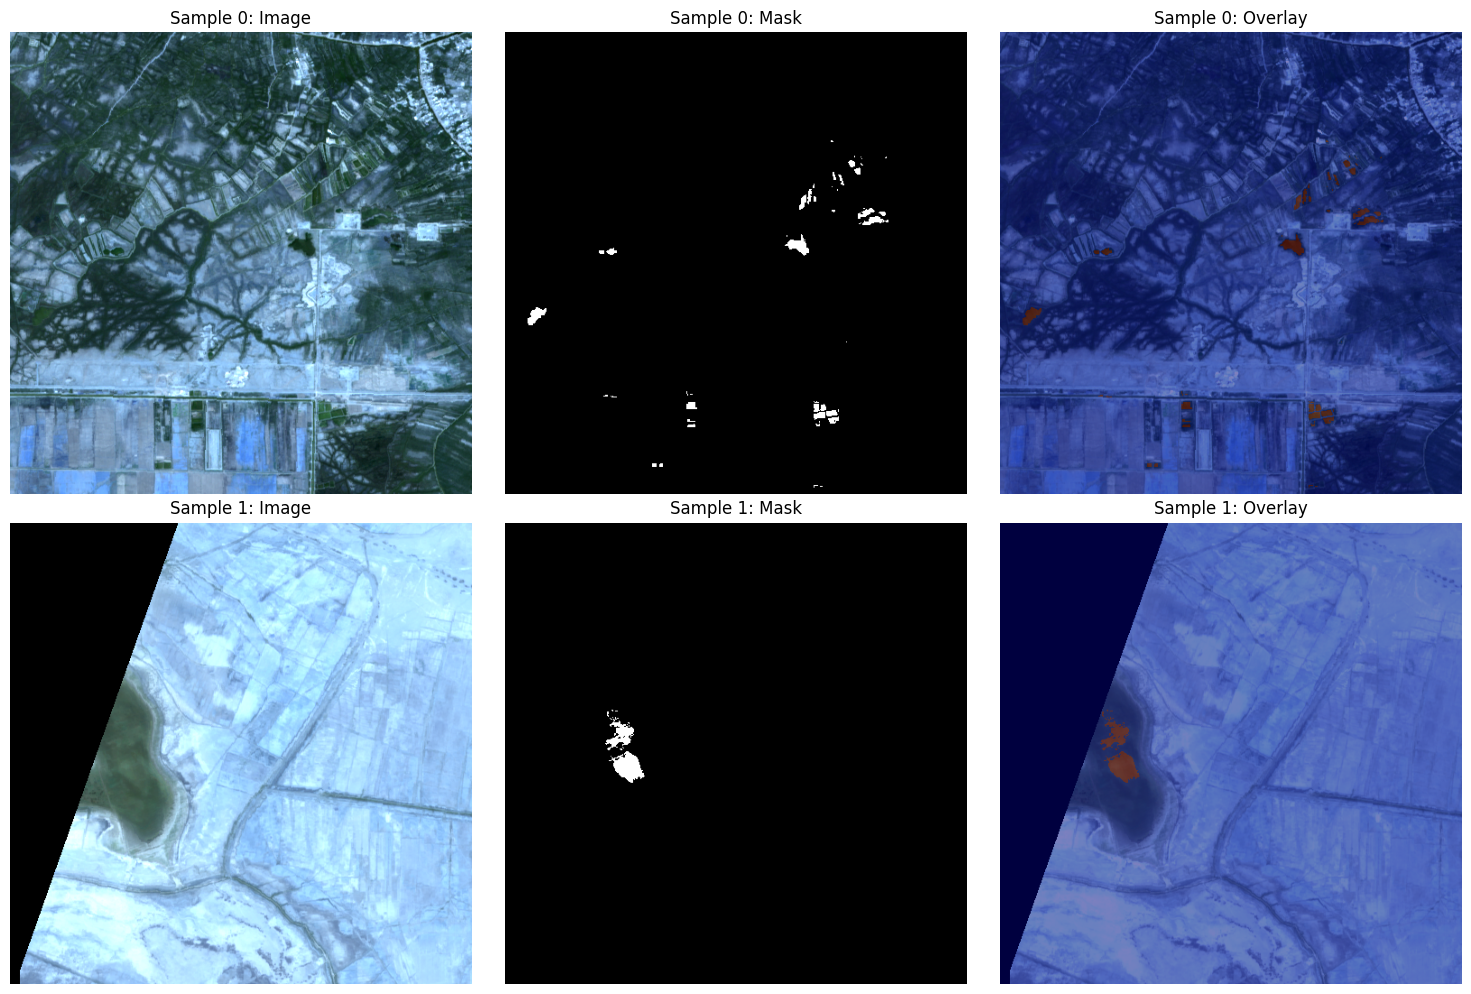


Mask value check:
Unique values in mask: [0 1]
Percentage of water (value=1): 0.65%
Percentage of non-water (value=0): 99.35%


In [89]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = 512

def preprocess_img_npy(img_array, size=IMG_SIZE):
    """Preprocess numpy array image to RGB float32."""
    arr = img_array.copy()

    # Already RGB from loading step, but verify
    if arr.ndim == 3 and arr.shape[-1] > 3:
        arr = arr[..., :3]

    # Determine value range and normalize
    if arr.max() > 1.0:
        # Assume 0-255 or 0-10000 range
        arr = arr.astype(np.float32) / arr.max()
    else:
        # Already in 0-1 range
        arr = arr.astype(np.float32)

    # Convert to uint8 for PIL
    arr_uint8 = (arr * 255.0).clip(0, 255).astype(np.uint8)

    # Resize using PIL
    img = Image.fromarray(arr_uint8, mode="RGB")
    img = img.resize((size, size), resample=Image.BILINEAR)

    # Convert back to float32 [0, 1]
    return np.asarray(img, dtype=np.float32) / 255.0

def preprocess_mask_npy(mask_array, size=IMG_SIZE):
    """Preprocess numpy array mask to binary uint8."""
    y = mask_array.copy()

    # Handle multi-dimensional masks
    if y.ndim == 3:
        y = y[..., 0]  # Take first channel

    # Binarize
    y = (y > 0).astype(np.uint8)

    # Resize if needed
    if y.shape[0] != size or y.shape[1] != size:
        y_img = Image.fromarray(y)
        y_img = y_img.resize((size, size), resample=Image.NEAREST)
        y = np.asarray(y_img, dtype=np.uint8)

    return y  # Return (512, 512) - NO extra dimension yet

# Apply preprocessing
print("\nPreprocessing training data...")
training_images_processed = [preprocess_img_npy(im) for im in training_images]
training_masks_processed = [preprocess_mask_npy(m) for m in training_masks]

print("Preprocessing validation data...")
validation_images_processed = [preprocess_img_npy(im) for im in validation_images]
validation_masks_processed = [preprocess_mask_npy(m) for m in validation_masks]

print("Preprocessing test data...")
test_images_processed = [preprocess_img_npy(im) for im in test_images]
test_masks_processed = [preprocess_mask_npy(m) for m in test_masks]

# Stack into simple arrays (no transpose, no reshape)
X_train = np.array(training_images_processed, dtype=np.float32)  # (N, 512, 512, 3)
Y_train = np.array(training_masks_processed, dtype=np.uint8)     # (N, 512, 512)
Y_train = Y_train[..., np.newaxis]  # Add channel: (N, 512, 512, 1)

X_val = np.array(validation_images_processed, dtype=np.float32)
Y_val = np.array(validation_masks_processed, dtype=np.uint8)
Y_val = Y_val[..., np.newaxis]

X_test = np.array(test_images_processed, dtype=np.float32)
Y_test = np.array(test_masks_processed, dtype=np.uint8)
Y_test = Y_test[..., np.newaxis]

# ==============================================================================
# DISPLAY RESULTS
# ==============================================================================

print("\n" + "="*60)
print("PREPROCESSED ARRAYS:")
print("="*60)
print(f"X_train: {X_train.shape} {X_train.dtype} range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Y_train: {Y_train.shape} {Y_train.dtype} unique: {np.unique(Y_train)}")
print(f"X_val  : {X_val.shape} {X_val.dtype} range: [{X_val.min():.3f}, {X_val.max():.3f}]")
print(f"Y_val  : {Y_val.shape} {Y_val.dtype} unique: {np.unique(Y_val)}")
print(f"X_test : {X_test.shape} {X_test.dtype} range: [{X_test.min():.3f}, {X_test.max():.3f}]")
print(f"Y_test : {Y_test.shape} {Y_test.dtype} unique: {np.unique(Y_test)}")
print("="*60)

# Visualize samples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(2):
    idx = i

    # Now shapes are clean: X_train[idx] is (512, 512, 3), Y_train[idx] is (512, 512, 1)
    img_display = X_train[idx]
    mask_display = Y_train[idx, :, :, 0]

    # Original image
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f'Sample {idx}: Image')
    axes[i, 0].axis('off')

    # Mask
    axes[i, 1].imshow(mask_display, cmap='gray')
    axes[i, 1].set_title(f'Sample {idx}: Mask')
    axes[i, 1].axis('off')

    # Overlay
    axes[i, 2].imshow(img_display)
    axes[i, 2].imshow(mask_display, cmap='jet', alpha=0.5)
    axes[i, 2].set_title(f'Sample {idx}: Overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Check mask values
print("\nMask value check:")
sample_mask = Y_train[0, :, :, 0]
print(f"Unique values in mask: {np.unique(sample_mask)}")
print(f"Percentage of water (value=1): {100 * np.sum(sample_mask == 1) / sample_mask.size:.2f}%")
print(f"Percentage of non-water (value=0): {100 * np.sum(sample_mask == 0) / sample_mask.size:.2f}%")

In [90]:
print("Train image:", np.array(training_images[0]).shape)
print("Train mask :", np.array(training_masks[0]).shape, np.unique(training_masks[0])[:10])


Train image: (512, 512, 3)
Train mask : (512, 512, 1) [0 1]


In [118]:
# Create TensorFlow dataset from validation arrays
validation_df = tf.data.Dataset.from_tensor_slices((v_images, v_masks))
validation_df = validation_df.batch(1)  # ← CRITICAL: Add batching to match training


In [116]:

def adjustData(img, mask, num_class):
    mask[mask > 0.5] = 1  # WATER
    mask[mask <= 0.5] = 0  # NON-WATER
    return (img, mask)

def trainGenerator(batch_size,
                   image_array,
                   mask_array,
                   aug_dict,
                   image_save_prefix="image",
                   mask_save_prefix="mask",
                   num_class=2,
                   save_to_dir=None,
                   target_size=(512, 512),
                   seed=1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array,
                                         batch_size=batch_size,
                                         save_to_dir=save_to_dir,
                                         save_prefix=image_save_prefix,
                                         seed=seed)

    mask_generator = mask_datagen.flow(mask_array,
                                       batch_size=batch_size,
                                       save_to_dir=save_to_dir,
                                       save_prefix=mask_save_prefix,
                                       seed=seed)

    train_generator = zip(image_generator, mask_generator)

    for (img, mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)


In [115]:

# ==============================================================================
# DATA AUGMENTATION PARAMETERS
# ==============================================================================

# Training augmentation (with transformations)
data_gen_args = dict(rotation_range=180,
                     width_shift_range=0.25,
                     height_shift_range=0.25,
                     shear_range=0.25,
                     zoom_range=0.25,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect')

# Validation augmentation (NO transformations)
validation_gen_args = dict()

# ==============================================================================
# CREATE GENERATORS - Use your preprocessed arrays directly
# ==============================================================================

# Training generator with augmentation
train = trainGenerator(1, X_train, Y_train, data_gen_args, save_to_dir=None)

# Validation generator without augmentation
validation_gen = trainGenerator(1, X_val, Y_val, validation_gen_args, save_to_dir=None)

# Ingest and Process 4-band Datasets

## 4-band Marshes dataset

In [94]:
base_dir2 = r"./content/Iraq_Marshes_s2_water_seg/"

In [95]:
base_dir2 = "/content/Iraq_Marshes_s2_water_seg/"

# Ingest images and normalize
def minmax_norm(a, eps=1e-8):
    """Per-image min-max normalization to [0, 1]."""
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    """Ensure mask is (H, W, 1) shape."""
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    """Filter for .npy files only."""
    return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
train_img_dir2  = os.path.join(base_dir2, "training", "images")
train_mask_dir2 = os.path.join(base_dir2, "training", "masks")

training_images_list2 = only_npy(os.listdir(train_img_dir2))[:250]
training_masks_list2 = []
training_images2 = []

for n in training_images_list2:
    training_masks_list2.append(n)  # Same filename for mask

    # Load image (H, W, 4) - rasterio format is (bands, H, W), np.load is (H, W, bands)
    a = np.load(os.path.join(train_img_dir2, n))
    a = minmax_norm(a)  # Normalize to [0, 1]
    training_images2.append(a)

## Training masks
training_masks2 = []
for n in training_masks_list2:
    a = np.load(os.path.join(train_mask_dir2, n))
    training_masks2.append(ensure_mask_hw1(a))

# =========================
# TEST (4-band)
# =========================
test_img_dir2  = os.path.join(base_dir2, "test", "images")
test_mask_dir2 = os.path.join(base_dir2, "test", "masks")

test_images_list2 = only_npy(os.listdir(test_img_dir2))
test_masks_list2 = []
test_images2 = []

for n in test_images_list2:
    test_masks_list2.append(n)

    a = np.load(os.path.join(test_img_dir2, n))
    a = minmax_norm(a)
    test_images2.append(a)

## Test masks
test_masks2 = []
for n in test_masks_list2:
    a = np.load(os.path.join(test_mask_dir2, n))
    test_masks2.append(ensure_mask_hw1(a))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir2  = os.path.join(base_dir2, "validation", "images")
val_mask_dir2 = os.path.join(base_dir2, "validation", "masks")

validation_images_list2 = only_npy(os.listdir(val_img_dir2))
validation_masks_list2 = []
validation_images2 = []

for n in validation_images_list2:
    validation_masks_list2.append(n)

    a = np.load(os.path.join(val_img_dir2, n))
    a = minmax_norm(a)
    validation_images2.append(a)

## Validation masks
validation_masks2 = []
for n in validation_masks_list2:
    a = np.load(os.path.join(val_mask_dir2, n))
    validation_masks2.append(ensure_mask_hw1(a))

# =========================
# Verify
# =========================
print("Loaded:")
print(f"Training: {len(training_images2)} images, {len(training_masks2)} masks")
print(f"Validation: {len(validation_images2)} images, {len(validation_masks2)} masks")
print(f"Test: {len(test_images2)} images, {len(test_masks2)} masks")

print(f"\nShapes:")
print(f"Training image: {training_images2[0].shape} dtype: {training_images2[0].dtype}")
print(f"Training mask: {training_masks2[0].shape} dtype: {training_masks2[0].dtype}")

print(f"\nValue ranges:")
print(f"Image range: [{training_images2[0].min():.3f}, {training_images2[0].max():.3f}]")
print(f"Mask unique: {np.unique(training_masks2[0])}")

Loaded:
Training: 143 images, 143 masks
Validation: 99 images, 99 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 4) dtype: float32
Training mask: (512, 512, 1) dtype: int32

Value ranges:
Image range: [0.000, 1.000]
Mask unique: [0 1]


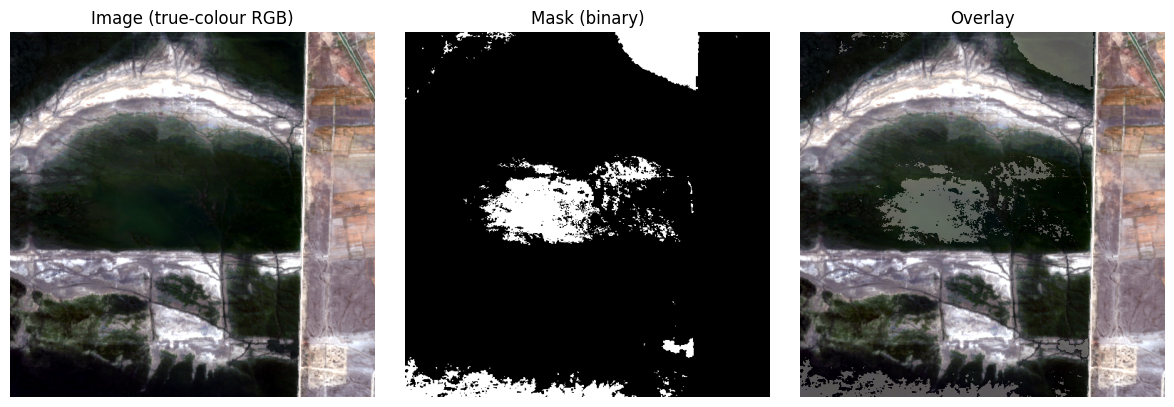

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [96]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [97]:
# =========================
# PRE-PROCESS DATA: RESHAPING AND TRANSPOSING
# =========================

for i in range(len(training_images2)):
    training_images2[i] = training_images2[i].astype('float32')
    training_images2[i] = training_images2[i].T

for i in range(len(training_masks2)):
    training_masks2[i] = training_masks2[i].reshape(1, 512, 512, 1)
    training_masks2[i] = training_masks2[i].T

for i in range(len(validation_images2)):
    validation_images2[i] = validation_images2[i].astype('float32')
    validation_images2[i] = validation_images2[i].T

for i in range(len(validation_masks2)):
    validation_masks2[i] = validation_masks2[i].reshape(1, 512, 512, 1)
    validation_masks2[i] = validation_masks2[i].T

for i in range(len(test_images2)):
    test_images2[i] = test_images2[i].astype('float32')
    test_images2[i] = test_images2[i].T

for i in range(len(test_masks2)):
    test_masks2[i] = test_masks2[i].reshape(1, 512, 512, 1)
    test_masks2[i] = test_masks2[i].T

for i in range(len(training_images2)):
    training_images2[i] = training_images2[i].reshape(-1, 512, 512, 4)

for i in range(len(validation_images2)):
    validation_images2[i] = validation_images2[i].reshape(-1, 512, 512, 4)

for i in range(len(test_images2)):
    test_images2[i] = test_images2[i].reshape(-1, 512, 512, 4)

# =========================
# VERIFY FINAL SHAPES
# =========================

print("\n" + "="*60)
print("AFTER PREPROCESSING:")
print("="*60)
print(f"Training image shape: {training_images2[0].shape}")
print(f"Training mask shape: {training_masks2[0].shape}")
print(f"Validation image shape: {validation_images2[0].shape}")
print(f"Validation mask shape: {validation_masks2[0].shape}")
print(f"Test image shape: {test_images2[0].shape}")
print(f"Test mask shape: {test_masks2[0].shape}")
print("="*60)



AFTER PREPROCESSING:
Training image shape: (1, 512, 512, 4)
Training mask shape: (1, 512, 512, 1)
Validation image shape: (1, 512, 512, 4)
Validation mask shape: (1, 512, 512, 1)
Test image shape: (1, 512, 512, 4)
Test mask shape: (1, 512, 512, 1)


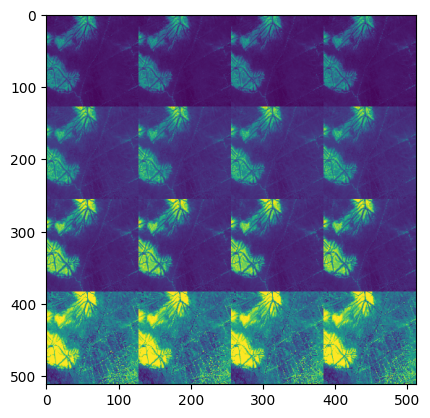

In [98]:
# Plot example training image first band
plt.imshow(training_images2[4].reshape(512,512,4)[:,:,0])

In [99]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_marshes = tf.data.Dataset.from_tensor_slices((training_images2[0:250], training_masks2[0:250]))
validation_df_4band_marshes = tf.data.Dataset.from_tensor_slices((validation_images2, validation_masks2))

## 4-band Lake dataset

In [100]:
# Specify whether to download data or read in
download = True
base_dir3 = "/content/Iraq_Lake_s2_water_seg/"

In [101]:
# Download data (Atlantic Forest)
if download:
    # Download data
    url = "https://zenodo.org/records/18471652/files/Iraq_Lake_s2_water_seg.zip?download=11"

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
        f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall("/content/")

    # confirm
    os.listdir("/content/")


In [102]:
base_dir3 = "/content/Iraq_Marshes_s2_water_seg/"

# Ingest images and normalize
def minmax_norm(a, eps=1e-8):
    """Per-image min-max normalization to [0, 1]."""
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    """Ensure mask is (H, W, 1) shape."""
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    """Filter for .npy files only."""
    return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
train_img_dir3  = os.path.join(base_dir3, "training", "images")
train_mask_dir3 = os.path.join(base_dir3, "training", "masks")

training_images_list3 = only_npy(os.listdir(train_img_dir3))[:250]
training_masks_list3 = []
training_images3 = []

for n in training_images_list3:
    training_masks_list3.append(n)  # Same filename for mask

    # Load image (H, W, 4) - rasterio format is (bands, H, W), np.load is (H, W, bands)
    a = np.load(os.path.join(train_img_dir3, n))
    a = minmax_norm(a)  # Normalize to [0, 1]
    training_images3.append(a)

## Training masks
training_masks3 = []
for n in training_masks_list3:
    a = np.load(os.path.join(train_mask_dir3, n))
    training_masks3.append(ensure_mask_hw1(a))

# =========================
# TEST (4-band)
# =========================
test_img_dir3  = os.path.join(base_dir3, "test", "images")
test_mask_dir3 = os.path.join(base_dir3, "test", "masks")

test_images_list3 = only_npy(os.listdir(test_img_dir3))
test_masks_list3 = []
test_images3 = []

for n in test_images_list3:
    test_masks_list3.append(n)

    a = np.load(os.path.join(test_img_dir3, n))
    a = minmax_norm(a)
    test_images3.append(a)

## Test masks
test_masks3 = []
for n in test_masks_list3:
    a = np.load(os.path.join(test_mask_dir3, n))
    test_masks3.append(ensure_mask_hw1(a))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir3  = os.path.join(base_dir3, "validation", "images")
val_mask_dir3 = os.path.join(base_dir3, "validation", "masks")

validation_images_list3 = only_npy(os.listdir(val_img_dir3))
validation_masks_list3 = []
validation_images3 = []

for n in validation_images_list3:
    validation_masks_list3.append(n)

    a = np.load(os.path.join(val_img_dir3, n))
    a = minmax_norm(a)
    validation_images3.append(a)

## Validation masks
validation_masks3 = []
for n in validation_masks_list3:
    a = np.load(os.path.join(val_mask_dir3, n))
    validation_masks3.append(ensure_mask_hw1(a))

# =========================
# Verify
# =========================
print("Loaded:")
print(f"Training: {len(training_images3)} images, {len(training_masks3)} masks")
print(f"Validation: {len(validation_images3)} images, {len(validation_masks3)} masks")
print(f"Test: {len(test_images3)} images, {len(test_masks3)} masks")

print(f"\nShapes:")
print(f"Training image: {training_images3[0].shape} dtype: {training_images3[0].dtype}")
print(f"Training mask: {training_masks3[0].shape} dtype: {training_masks3[0].dtype}")

print(f"\nValue ranges:")
print(f"Image range: [{training_images3[0].min():.3f}, {training_images3[0].max():.3f}]")
print(f"Mask unique: {np.unique(training_masks3[0])}")

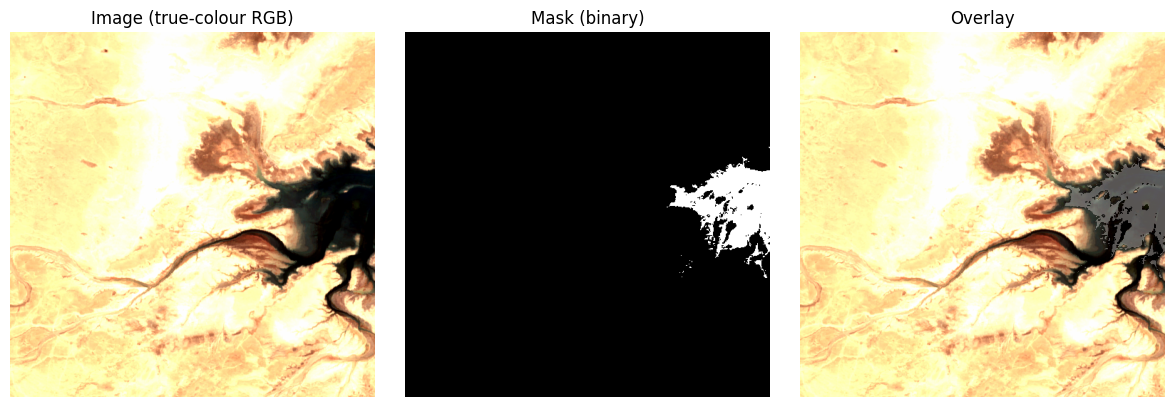

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.03725433349609375


In [103]:
# Show example train image

fname = "tharthar_2021_r015_c008.npy"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir3, split, "images", fname)
mask_path = os.path.join(base_dir3, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [104]:
# =========================
# PRE-PROCESS DATA: RESHAPING AND TRANSPOSING
# =========================

# Images: convert to float32 and transpose
for i in range(len(training_images3)):
    training_images3[i] = training_images3[i].astype('float32')
    training_images3[i] = training_images3[i].T

for i in range(len(validation_images3)):
    validation_images3[i] = validation_images3[i].astype('float32')
    validation_images3[i] = validation_images3[i].T

for i in range(len(test_images3)):
    test_images3[i] = test_images3[i].astype('float32')
    test_images3[i] = test_images3[i].T

# Masks: ensure correct shape before transpose
for i in range(len(training_masks3)):
    # Current shape is (512, 512, 1), need to add batch dimension
    if training_masks3[i].ndim == 3:
        training_masks3[i] = training_masks3[i][np.newaxis, ...]  # (1, 512, 512, 1)
    training_masks3[i] = training_masks3[i].T

for i in range(len(validation_masks3)):
    if validation_masks3[i].ndim == 3:
        validation_masks3[i] = validation_masks3[i][np.newaxis, ...]
    validation_masks3[i] = validation_masks3[i].T

for i in range(len(test_masks3)):
    if test_masks3[i].ndim == 3:
        test_masks3[i] = test_masks3[i][np.newaxis, ...]
    test_masks3[i] = test_masks3[i].T

# Final reshape for images
for i in range(len(training_images3)):
    training_images3[i] = training_images3[i].reshape(-1, 512, 512, 4)

for i in range(len(validation_images3)):
    validation_images3[i] = validation_images3[i].reshape(-1, 512, 512, 4)

for i in range(len(test_images3)):
    test_images3[i] = test_images3[i].reshape(-1, 512, 512, 4)

# =========================
# VERIFY FINAL SHAPES
# =========================

print("\n" + "="*60)
print("AFTER PREPROCESSING:")
print("="*60)
print(f"Training image shape: {training_images3[0].shape}")
print(f"Training mask shape: {training_masks3[0].shape}")
print(f"Validation image shape: {validation_images3[0].shape}")
print(f"Validation mask shape: {validation_masks3[0].shape}")
print(f"Test image shape: {test_images3[0].shape}")
print(f"Test mask shape: {test_masks3[0].shape}")
print("="*60)

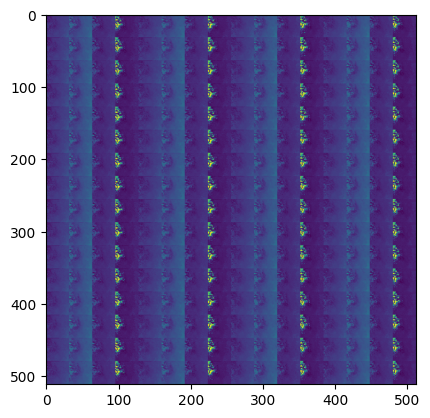

In [105]:
# Plot example training image first band
plt.imshow(training_images3[0].reshape(512,512,4)[:,:,0])

In [106]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_lakes = tf.data.Dataset.from_tensor_slices((training_images3[0:250], training_masks3[0:250]))
validation_df_4band_lakes = tf.data.Dataset.from_tensor_slices((validation_images3, validation_masks3))

# Models

## U-Net

In [112]:
'''
  Convolutional block with set parameters and activation layer after
'''

def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
  else:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)

  conv = Activation(act)(conv)
  return conv

'''
  U-Net model
'''

def UNet(trained_weights = None, input_size = (512,512,4), drop_rate = 0.25, lr=0.0001):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size)

    ## Contraction phase
    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    #drop2 = Dropout(drop_rate)(pool2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    #drop3 = Dropout(drop_rate)(pool3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    #drop4 = Dropout(drop_rate)(pool4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    ## Expansion phase
    up6 = (Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = concatenate([conv4,up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)
    #conv6 = Dropout(drop_rate)(conv6)

    up7 = (Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = concatenate([conv3,up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)
    #conv7 = Dropout(drop_rate)(conv7)

    up8 = (Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7))
    merge8 = concatenate([conv2,up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)
    #conv8 = Dropout(drop_rate)(conv8)

    up9 = (Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8))
    merge9 = concatenate([conv1,up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    # Output layer
    conv10 = convBlock(conv9, 1, 1, act='sigmoid')

    model = Model(inputs, conv10)

    model.compile(optimizer = Adam(learning_rate = lr), loss = 'binary_crossentropy', metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [113]:
# Print model layers and number of parameters
UNet().summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 512, 512,  │      2,368 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_65       │ (None, 512, 512,  │          0 │ conv2d_69[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 512, 512,  │     36,928 │ activation_65[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_66       │ (None, 512, 512,  │          0 │ conv2d_70[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 256, 256,  │          0 │ activation_66[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_67       │ (None, 256, 256,  │          0 │ conv2d_71[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 256, 256,  │    147,584 │ activation_67[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 256, 256,  │          0 │ conv2d_72[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 128, 128,  │          0 │ activation_68[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_17… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 128, 128,  │          0 │ conv2d_73[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 128, 128,  │    590,080 │ activation_69[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 128, 128,  │          0 │ conv2d_74[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 64, 64,    │          0 │ activation_70[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_18

 Total params: 31,032,321 (118.38 MB)

 Trainable params: 31,032,321 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

## Attention U-Net

In [109]:
'''
  Convolutional block with two conv layers and two activation layers
'''

def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)

  return conv

'''
  Attention block/mechanism
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):

    # Find shape of inputs
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    ## Process x vector and gating signal
    # x vector input and processing
    theta_x = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2,2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    # gating signal ""
    phi_g = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(gating)
    shape_phi_g = K.int_shape(phi_g)

    # Add components
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    # Apply convolution
    psi = Conv2D(1, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)

    # Apply sigmoid activation
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    # UpSample and resample to correct size
    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    y = multiply([upsample_psi, x])

    return y


'''
  Attention U-Net model
'''

def UNetAM(trained_weights = None, input_size = (512,512,3), drop_rate = 0.25, lr=0.0001, filter_base=16):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv = convBlock2(inputs, filter_base, 3)
    #conv0 = Dropout(drop_rate)(conv0)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)
    #conv1 = Dropout(drop_rate)(conv1)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)
    #conv2 = Dropout(drop_rate)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)
    #conv3 = Dropout(drop_rate)(conv3)

    ## Expansion phase
    up4 = (Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3))
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate) # Attention gate
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = (Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4))
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate) # Attention gate
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = (Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate) # Attention gate
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = (Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate) # Attention gate
    conv7 = concatenate([up7, merge7])
    conv7 = concatenate([up7, conv])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    ## Output layer
    out = convBlock(conv7, 1, 1, act='sigmoid')

    model = Model(inputs, out)

    model.compile(optimizer = Adam(learning_rate = lr), loss = binary_crossentropy, metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [110]:
# Print model layers and number of parameters
UNetAM().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (1, 512, 512, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (1, 512, 512, 16) │        448 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (1, 512, 512, 16) │          0 │ conv2d_19[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (1, 512, 512, 16) │      2,320 │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (1, 512, 512, 16) │          0 │ conv2d_20[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (1, 256, 256, 16) │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (1, 256, 256, 32) │      4,640 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (1, 256, 256, 32) │          0 │ conv2d_21[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (1, 256, 256, 32) │      9,248 │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (1, 256, 256, 32) │          0 │ conv2d_22[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (1, 128, 128, 32) │          0 │ activation_22[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (1, 128, 128, 64) │     18,496 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (1, 128, 128, 64) │          0 │ conv2d_23[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (1, 128, 128, 64) │     36,928 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (1, 128, 128, 64) │          0 │ conv2d_24[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (1, 64, 64, 64)   │          0 │ activation_24[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (1, 64, 64, 128)  │     73,856 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (1, 64, 64, 128)  │          0 │ conv2d_25[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (1, 64, 64, 128)  │    147,584 │ activation_25[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,006,292 (7.65 MB)

 Trainable params: 2,006,292 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

# Train on RGB feature data

## U-Net

In [122]:
# Train U-Net with generator
model_unet = UNet(input_size=(512,512,3), lr=0.0001)
save_model = ModelCheckpoint('unet-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

model_unet.fit(train, steps_per_epoch=100, epochs=2, validation_data=validation_df, callbacks=[save_model])

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8860 - loss: 0.4226 - mse: 0.1249
Epoch 1: val_accuracy improved from -inf to 0.94139, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 159ms/step - accuracy: 0.8859 - loss: 0.4226 - mse: 0.1249 - val_accuracy: 0.9414 - val_loss: 0.2170 - val_mse: 0.0711
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8963 - loss: 0.2682 - mse: 0.0852
Epoch 2: val_accuracy improved from 0.94139 to 0.95430, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.8963 - loss: 0.2679 - mse: 0.0851 - val_accuracy: 0.9543 - val_loss: 0.0993 - val_mse: 0.0310


In [123]:
# Save model training history
np.save('unet-3d-history.npy',model_unet.history)


In [124]:
# Copy models to drive
!cp unet-3d.keras drive/MyDrive/Diss/
!cp unet-3d-history.npy drive/MyDrive/Diss/

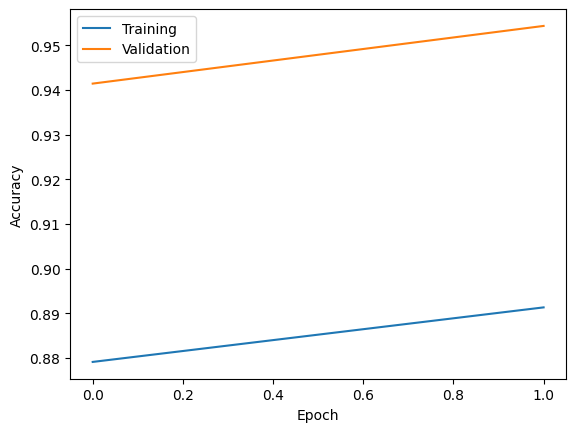

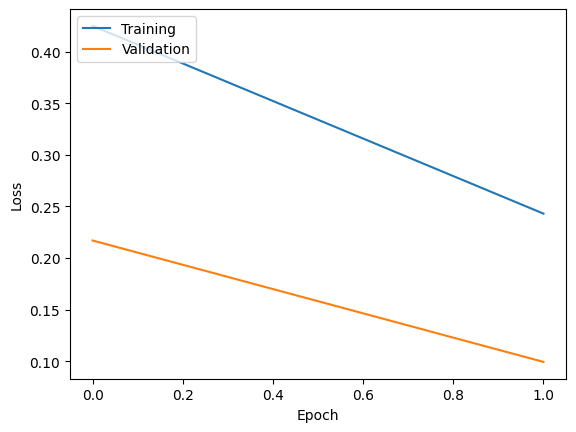

In [125]:
# Plot accuracy and loss

## Accuracy
plt.plot(model_unet.history.history['accuracy'])
plt.plot(model_unet.history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(model_unet.history.history['loss'])
plt.plot(model_unet.history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

## Attention U-Net

In [126]:
# Train Attention U-Net with generator
model_attention_unet = UNetAM(lr=0.0005, filter_base=16)
save_model_am = ModelCheckpoint('unet-attention-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)
model_attention_unet.fit(train, steps_per_epoch=100, epochs=2, validation_data = validation_df, callbacks=[save_model_am])

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8835 - loss: 0.5600 - mse: 0.1440
Epoch 1: val_accuracy improved from -inf to 0.94139, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 121ms/step - accuracy: 0.8834 - loss: 0.5597 - mse: 0.1439 - val_accuracy: 0.9414 - val_loss: 0.2332 - val_mse: 0.0759
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8961 - loss: 0.3018 - mse: 0.0972
Epoch 2: val_accuracy improved from 0.94139 to 0.94140, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8960 - loss: 0.3017 - mse: 0.0972 - val_accuracy: 0.9414 - val_loss: 0.1535 - val_mse: 0.0454


In [127]:
# Save model history
np.save('unet-attention-3d-history.npy',model_attention_unet.history)

In [128]:
# Copy models to drive
!cp unet-attention-3d.keras drive/MyDrive/Diss/
!cp unet-attention-3d-history.npy drive/MyDrive/Diss/

# Train on 4-band data

## Train on 4-band Amazon data

### U-Net

In [129]:
# Train U-Net with generator
model_unet_4band = UNet()
save_model_4band = ModelCheckpoint('unet-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band.fit(train_df_4band_marshes, epochs=2, validation_data = validation_df_4band_marshes, callbacks=[save_model_4band])

Epoch 1/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8538 - loss: 0.7057 - mse: 0.1556
Epoch 1: val_accuracy improved from -inf to 0.94140, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 142ms/step - accuracy: 0.8540 - loss: 0.7045 - mse: 0.1555 - val_accuracy: 0.9414 - val_loss: 0.2495 - val_mse: 0.0712
Epoch 2/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8967 - loss: 0.3595 - mse: 0.1026
Epoch 2: val_accuracy improved from 0.94140 to 0.94140, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.8966 - loss: 0.3595 - mse: 0.1025 - val_accuracy: 0.9414 - val_loss: 0.1846 - val_mse: 0.0490


In [130]:
# Save model history
np.save('unet-4d-history.npy',model_unet_4band.history.history)

In [131]:
# Copy models to drive
!cp unet-4d.keras drive/MyDrive/Diss/
!cp unet-4d-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [132]:
# Train U-Net with generator
model_attention_unet_4band = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention = ModelCheckpoint('unet-attention-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band.fit(train_df_4band_marshes, epochs = 2, validation_data = validation_df_4band_marshes, callbacks=[save_model_4band_attention])

Epoch 1/2
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8319 - loss: 0.5162 - mse: 0.1636
Epoch 1: val_accuracy improved from -inf to 0.94140, saving model to unet-attention-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8325 - loss: 0.5151 - mse: 0.1631 - val_accuracy: 0.9414 - val_loss: 0.1932 - val_mse: 0.0504
Epoch 2/2
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8967 - loss: 0.3267 - mse: 0.0920
Epoch 2: val_accuracy did not improve from 0.94140
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8966 - loss: 0.3269 - mse: 0.0920 - val_accuracy: 0.9414 - val_loss: 0.1866 - val_mse: 0.0496


In [133]:
# Save model history
np.save('unet-attention-4d-history.npy',model_attention_unet_4band.history.history)

In [134]:
# Copy models to drive
!cp unet-attention-4d.keras drive/MyDrive/Diss/
!cp unet-attention-4d-history.npy drive/MyDrive/Diss/

## Train on 4-band Lakes data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band_lakes = UNet()
save_model_4band_lakes = ModelCheckpoint('unet-4d-lakes.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band_lakes.fit(train_df_4band_lakes, epochs = 2, validation_data = validation_df_4band_lakes, callbacks=[save_model_4band_lakes])

Epoch 1/2
104/250 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.6081 - loss: 0.7314 - mse: 0.2543

In [ ]:
# Save model history
np.save('unet-4d-lakes-history.npy',model_unet_4band_lakes.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d-lakes.hdf5 drive/MyDrive/Diss/
!cp unet-4d-lakes-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet_4band_lakes = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention_lakes = ModelCheckpoint('unet-attention-4d-lakes.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band_lakes.fit(train_df_4band_lakes, epochs = 2, validation_data = validation_df_4band_lakes, callbacks=[save_model_4band_attention_lakes])

In [ ]:
# Save model history
np.save('unet-attention-4d-lakes-history.npy',model_attention_unet_4band_lakes.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d-lakes.hdf5 drive/MyDrive/Diss/
!cp unet-attention-4d-lakes-history.npy drive/MyDrive/Diss/

# Import Models and Compute Metrics

## RGB

In [ ]:
# Load 3-dim models and history stats
attention_unet = load_model('unet-attention-3d.keras')
unet = load_model('unet-3d.keras')

unet_history = np.load('unet-3d-history.npy', allow_pickle='TRUE').item()
attention_unet_history = np.load('unet-attention-3d-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_history['accuracy'])
plt.plot(unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_history['loss'])
plt.plot(unet_history['val_loss'])
plt.ylabel('Loss', size=12)
plt.xlabel('Epoch', size=12)
plt.legend(['Training', 'Validation'], loc='lower right')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_history['accuracy'])
plt.plot(attention_unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## Loss
plt.plot(attention_unet_history['loss'])
plt.plot(attention_unet_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

In [ ]:
# Scores of each model
unet_score = (score_eval(unet, validation_images, validation_masks))
am_unet_score = (score_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# Precision and recall of each model
unet_precision = (precision_eval(unet, validation_images, validation_masks))
am_unet_precision = (precision_eval(attention_unet, validation_images, validation_masks))

unet_recall = (recall_eval(unet, validation_images, validation_masks))
am_unet_recall = (recall_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# F1-scores of each model
unet_f1_score = (f1_score_eval_basic(unet_precision, unet_recall))
am_unet_f1_score = (f1_score_eval_basic(am_unet_precision, am_unet_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_score), np.std(unet_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_score), np.std(am_unet_score))

In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_precision), np.std(unet_precision))
print('Attention U-Net precision: ', np.mean(am_unet_precision), np.std(am_unet_precision))

In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_recall), np.std(unet_recall))
print('Attention U-Net recall: ', np.mean(am_unet_recall), np.std(am_unet_recall))

In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_f1_score))

## 4-band

### Marshes Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d = load_model('unet-attention-4d.keras')
unet_4d = load_model('unet-4d.keras')

unet_4d_history = np.load('unet-4d-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_history = np.load('unet-attention-4d-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_history['accuracy'])
plt.plot(unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_history['loss'])
plt.plot(unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_history['accuracy'])
plt.plot(attention_unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_history['loss'])
plt.plot(attention_unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_score = (score_eval2(unet_4d, validation_images2, validation_masks2))
am_unet_4d_score = (score_eval2(attention_unet_4d, validation_images2, validation_masks2))

In [ ]:
# Precision and recall of each model
unet_4d_precision = (precision_eval(unet_4d, validation_images2, validation_masks2))
am_unet_4d_precision = (precision_eval(attention_unet_4d, validation_images2, validation_masks2))

unet_4d_recall = (recall_eval(unet_4d, validation_images2, validation_masks2))
am_unet_4d_recall = (recall_eval(attention_unet_4d, validation_images2, validation_masks2))

In [ ]:
# F1-scores of each model
unet_4d_f1_score = (f1_score_eval_basic(unet_4d_precision, unet_4d_recall))
am_unet_4d_f1_score = (f1_score_eval_basic(am_unet_4d_precision, am_unet_4d_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_4d_score), np.std(unet_4d_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_4d_score), np.std(am_unet_4d_score))

In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_4d_precision), np.std(unet_4d_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision), np.std(am_unet_4d_precision))

In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_4d_recall), np.std(unet_4d_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall), np.std(am_unet_4d_recall))

In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_4d_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_4d_f1_score))

### Marshes on unseen Lakes data

In [ ]:
# Score
unet_amazon_on_atlantic_score = score_eval2(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3)
am_unet_amazon_on_atlantic_score = score_eval2(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3)

# Precision
unet_amazon_on_atlantic_precision = (precision_eval(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))
am_unet_amazon_on_atlantic_precision = (precision_eval(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))

# Recall
unet_amazon_on_atlantic_recall = (recall_eval(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))
am_unet_amazon_on_atlantic_recall = (recall_eval(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))

# F1-scores of each model
unet_amazon_on_atlantic_f1_score = (f1_score_eval_basic(unet_amazon_on_atlantic_precision, unet_amazon_on_atlantic_recall))
am_unet_amazon_on_atlantic_f1_score = (f1_score_eval_basic(am_unet_amazon_on_atlantic_precision, am_unet_amazon_on_atlantic_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_amazon_on_atlantic_score), np.std(unet_amazon_on_atlantic_score))
print('Attention U-Net score: ', np.mean(am_unet_amazon_on_atlantic_score), np.std(am_unet_amazon_on_atlantic_score))

print('U-Net precision: ', np.mean(unet_amazon_on_atlantic_precision), np.std(unet_amazon_on_atlantic_precision))
print('Attention U-Net precision: ', np.mean(am_unet_amazon_on_atlantic_precision), np.std(am_unet_amazon_on_atlantic_precision))

print('U-Net recall: ', np.mean(unet_amazon_on_atlantic_recall), np.std(unet_amazon_on_atlantic_recall))
print('Attention U-Net recall: ', np.mean(am_unet_amazon_on_atlantic_recall), np.std(am_unet_amazon_on_atlantic_recall))

print('U-Net F1-score: ', unet_amazon_on_atlantic_f1_score)
print('Attention U-Net F1-score: ', am_unet_amazon_on_atlantic_f1_score)

### Lakes Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d_atlantic = load_model('unet-attention-4d-atlantic.keras')
unet_4d_atlantic = load_model('unet-4d-atlantic.keras')

unet_4d_atlantic_history = np.load('unet-4d-atlantic-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_atlantic_history = np.load('unet-attention-4d-atlantic-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_atlantic_history['accuracy'])
plt.plot(unet_4d_atlantic_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_atlantic_history['loss'])
plt.plot(unet_4d_atlantic_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_atlantic_history['accuracy'])
plt.plot(attention_unet_4d_atlantic_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_atlantic_history['loss'])
plt.plot(attention_unet_4d_atlantic_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_atlantic_score = (score_eval2(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_score = (score_eval2(attention_unet_4d_atlantic, validation_images3, validation_masks3))

# Precision and recall of each model
unet_4d_atlantic_precision = (precision_eval(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_precision = (precision_eval(attention_unet_4d_atlantic, validation_images3, validation_masks3))

unet_4d_atlantic_recall = (recall_eval(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_recall = (recall_eval(attention_unet_4d_atlantic, validation_images3, validation_masks3))

# F1-scores of each model
unet_4d_atlantic_f1_score = (f1_score_eval_basic(unet_4d_atlantic_precision, unet_4d_atlantic_recall))
am_unet_4d_atlantic_f1_score = (f1_score_eval_basic(am_unet_4d_atlantic_precision, am_unet_4d_atlantic_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_4d_atlantic_score), np.std(unet_4d_atlantic_score))
print('Attention U-Net score: ', np.mean(am_unet_4d_atlantic_score), np.std(am_unet_4d_atlantic_score))

print('U-Net precision: ', np.mean(unet_4d_atlantic_precision), np.std(unet_4d_atlantic_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_atlantic_precision), np.std(am_unet_4d_atlantic_precision))

print('U-Net recall: ', np.mean(unet_4d_atlantic_recall), np.std(unet_4d_atlantic_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_atlantic_recall), np.std(am_unet_4d_atlantic_recall))

print('U-Net F1-score: ', unet_4d_atlantic_f1_score)
print('Attention U-Net F1-score: ', am_unet_4d_atlantic_f1_score)

### Lakes on unseen Marshes data

In [ ]:
# Score
unet_atlantic_on_amazon_score = score_eval2(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2)
am_unet_atlantic_on_amazon_score = score_eval2(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2)

# Precision
unet_atlantic_on_amazon_precision = (precision_eval(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))
am_unet_atlantic_on_amazon_precision = (precision_eval(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# Recall
unet_atlantic_on_amazon_recall = (recall_eval(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))
am_unet_atlantic_on_amazon_recall = (recall_eval(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# F1-scores of each model
unet_atlantic_on_amazon_f1_score = (f1_score_eval_basic(unet_atlantic_on_amazon_precision, unet_atlantic_on_amazon_recall))
am_unet_atlantic_on_amazon_f1_score = (f1_score_eval_basic(am_unet_atlantic_on_amazon_precision, am_unet_atlantic_on_amazon_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_atlantic_on_amazon_score), np.std(unet_atlantic_on_amazon_score))
print('Attention U-Net score: ', np.mean(am_unet_atlantic_on_amazon_score), np.std(am_unet_atlantic_on_amazon_score))

print('U-Net precision: ', np.mean(unet_atlantic_on_amazon_precision), np.std(unet_atlantic_on_amazon_precision))
print('Attention U-Net precision: ', np.mean(am_unet_atlantic_on_amazon_precision), np.std(am_unet_atlantic_on_amazon_precision))

print('U-Net recall: ', np.mean(unet_atlantic_on_amazon_recall), np.std(unet_atlantic_on_amazon_recall))
print('Attention U-Net recall: ', np.mean(am_unet_atlantic_on_amazon_recall), np.std(am_unet_atlantic_on_amazon_recall))

print('U-Net F1-score: ', unet_atlantic_on_amazon_f1_score)
print('Attention U-Net F1-score: ', am_unet_atlantic_on_amazon_f1_score)

### Marshes and Lakes unseen test data

In [ ]:
# Amazon trained model on Amazon test data
# Scores of each model
unet_4d_score_test = (score_eval2(unet_4d, test_images2, test_masks2))
am_unet_4d_score_test = (score_eval2(attention_unet_4d, test_images2, test_masks2))

# Precision and recall of each model
unet_4d_precision_test = (precision_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_precision_test = (precision_eval(attention_unet_4d, test_images2, test_masks2))

unet_4d_recall_test = (recall_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_recall_test = (recall_eval(attention_unet_4d, test_images2, test_masks2))

# F1-scores of each model
unet_4d_f1_score_test = (f1_score_eval_basic(unet_4d_precision_test, unet_4d_recall_test))
am_unet_4d_f1_score_test = (f1_score_eval_basic(am_unet_4d_precision_test, am_unet_4d_recall_test))

In [ ]:
# Atlantic trained model on Atlantic test data
# Scores of each model
unet_4d_atlantic_score_test = (score_eval2(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_score_test = (score_eval2(attention_unet_4d_atlantic, test_images3, test_masks3))

# Precision and recall of each model
unet_4d_atlantic_precision_test = (precision_eval(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_precision_test = (precision_eval(attention_unet_4d_atlantic, test_images3, test_masks3))

unet_4d_atlantic_recall_test = (recall_eval(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_recall_test = (recall_eval(attention_unet_4d_atlantic, test_images3, test_masks3))

# F1-scores of each model
unet_4d_atlantic_f1_score_test = (f1_score_eval_basic(unet_4d_atlantic_precision_test, unet_4d_atlantic_recall_test))
am_unet_4d_atlantic_f1_score_test = (f1_score_eval_basic(am_unet_4d_atlantic_precision_test, am_unet_4d_atlantic_recall_test))

In [ ]:
# Print metrics for Amazon on Amazon Test set
print('U-Net score: ', np.mean(unet_4d_score_test), np.std(unet_4d_score_test))
print('Attention U-Net score: ', np.mean(am_unet_4d_score_test), np.std(am_unet_4d_score_test))

print('U-Net precision: ', np.mean(unet_4d_precision_test), np.std(unet_4d_precision_test))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision_test), np.std(am_unet_4d_precision_test))

print('U-Net recall: ', np.mean(unet_4d_recall_test), np.std(unet_4d_recall_test))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall_test), np.std(am_unet_4d_recall_test))

print('U-Net F1-score: ', unet_4d_f1_score_test)
print('Attention U-Net F1-score: ', am_unet_4d_f1_score_test)

In [ ]:
# Print metrics for Atlantic on Atlantic Test set
print('U-Net score: ', np.mean(unet_4d_atlantic_score_test), np.std(unet_4d_atlantic_score_test))
print('Attention U-Net score: ', np.mean(am_unet_4d_atlantic_score_test), np.std(am_unet_4d_atlantic_score_test))

print('U-Net precision: ', np.mean(unet_4d_atlantic_precision_test), np.std(unet_4d_atlantic_precision_test))
print('Attention U-Net precision: ', np.mean(am_unet_4d_atlantic_precision_test), np.std(am_unet_4d_atlantic_precision_test))

print('U-Net recall: ', np.mean(unet_4d_atlantic_recall_test), np.std(unet_4d_atlantic_recall_test))
print('Attention U-Net recall: ', np.mean(am_unet_4d_atlantic_recall_test), np.std(am_unet_4d_atlantic_recall_test))

print('U-Net F1-score: ', unet_4d_atlantic_f1_score_test)
print('Attention U-Net F1-score: ', am_unet_4d_atlantic_f1_score_test)

# Produce metric datasets for export

## RGB data

In [ ]:
scores_3d = [unet_score, am_unet_score, resnet_3d_score, fcn32_3d_score, resunet_3d_score]
precision_3d = [unet_precision, am_unet_precision, resnet_3d_precision, fcn32_3d_precision, resunet_3d_precision]
recall_3d = [unet_recall, am_unet_recall, resnet_3d_recall, fcn32_3d_recall, resunet_3d_recall]
f1_scores_3d = [unet_f1_score, am_unet_f1_score, resnet_3d_f1_score, fcn32_3d_f1_score, resunet_3d_f1_score]

import pandas as pd
metrics_3d = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_3d],
              'precision': [np.mean(n) for n in precision_3d],
              'recall': [np.mean(n) for n in recall_3d],
              'f1_score': [np.mean(n) for n in f1_scores_3d],
              'accuracy_std': [np.std(n) for n in scores_3d],
              'precision_std': [np.std(n) for n in precision_3d],
              'recall_std': [np.std(n) for n in recall_3d]
              }
metrics_3d = pd.DataFrame(metrics_3d)
metrics_3d.to_csv('metrics_3d.csv')

## 4-band Amazon data

In [ ]:
scores_4d = [unet_4d_score, am_unet_4d_score, resnet_4d_marshes_score, fcn32_4d_marshes_score, resunet_4d_marshes_score]
precision_4d = [unet_4d_precision, am_unet_4d_precision, resnet_4d_marshes_precision, fcn32_4d_marshes_precision, resunet_4d_marshes_precision]
recall_4d = [unet_4d_recall, am_unet_4d_recall, resnet_4d_marshes_recall, fcn32_4d_marshes_recall, resunet_4d_marshes_recall]
f1_scores_4d = [unet_4d_f1_score, am_unet_4d_f1_score, resnet_4d_marshes_f1_score, fcn32_4d_marshes_f1_score, resunet_4d_marshes_f1_score]

metrics_4d = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d],
              'precision': [np.mean(n) for n in precision_4d],
              'recall': [np.mean(n) for n in recall_4d],
              'f1_score': [np.mean(n) for n in f1_scores_4d],
              'accuracy_std': [np.std(n) for n in scores_4d],
              'precision_std': [np.std(n) for n in precision_4d],
              'recall_std': [np.std(n) for n in recall_4d]
              }
metrics_4d = pd.DataFrame(metrics_4d)
metrics_4d.to_csv('metrics_4d_amazon.csv')

## 4-band Atlantic Forest data

In [ ]:
scores_4d_atl = [unet_4d_atlantic_score, am_unet_4d_atlantic_score, resnet_4d_lakes_score, fcn32_4d_lakes_score, resunet_4d_lakes_score]
precision_4d_atl = [unet_4d_atlantic_precision, am_unet_4d_atlantic_precision, resnet_4d_lakes_precision, fcn32_4d_lakes_precision, resunet_4d_lakes_precision]
recall_4d_atl = [unet_4d_atlantic_recall, am_unet_4d_atlantic_recall, resnet_4d_lakes_recall, fcn32_4d_lakes_recall, resunet_4d_lakes_recall]
f1_scores_4d_atl = [unet_4d_atlantic_f1_score, am_unet_4d_atlantic_f1_score, resnet_4d_lakes_f1_score, fcn32_4d_lakes_f1_score, resunet_4d_lakes_f1_score]

metrics_4d_atl = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_atl],
              'precision': [np.mean(n) for n in precision_4d_atl],
              'recall': [np.mean(n) for n in recall_4d_atl],
              'f1_score': [np.mean(n) for n in f1_scores_4d_atl],
              'accuracy_std': [np.std(n) for n in scores_4d_atl],
              'precision_std': [np.std(n) for n in precision_4d_atl],
              'recall_std': [np.std(n) for n in recall_4d_atl]
              }
metrics_4d_atl = pd.DataFrame(metrics_4d_atl)
metrics_4d_atl.to_csv('metrics_4d_atlantic_forest.csv')

## Test set data

In [ ]:
scores_4d_test = [unet_4d_score_test, am_unet_4d_score_test, resnet_4d_score_test, fcn32_4d_score_test, resunet_4d_score_test]
precision_4d_test = [unet_4d_precision_test, am_unet_4d_precision_test, resnet_4d_precision_test, fcn32_4d_precision_test, resunet_4d_precision_test]
recall_4d_test = [unet_4d_recall_test, am_unet_4d_recall_test, resnet_4d_recall_test, fcn32_4d_recall_test, resunet_4d_recall_test]
f1_scores_4d_test = [unet_4d_f1_score_test, am_unet_4d_f1_score_test]

metrics_4d_test = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_test],
              'precision': [np.mean(n) for n in precision_4d_test],
              'recall': [np.mean(n) for n in recall_4d_test],
              'f1_score': [np.mean(n) for n in f1_scores_4d_test],
              'accuracy_std': [np.std(n) for n in scores_4d_test],
              'precision_std': [np.std(n) for n in precision_4d_test],
              'recall_std': [np.std(n) for n in recall_4d_test]
              }
metrics_4d_test = pd.DataFrame(metrics_4d_test)
metrics_4d_test.to_csv('metrics_4d_amazon_test.csv')

In [ ]:
scores_4d_atl_test = [unet_4d_atlantic_score_test, am_unet_4d_atlantic_score_test, resnet_4d_atlantic_score_test, fcn32_4d_atlantic_score_test, resunet_4d_atlantic_score_test]
precision_4d_atl_test = [unet_4d_atlantic_precision_test, am_unet_4d_atlantic_precision_test, resnet_4d_atlantic_precision_test, fcn32_4d_atlantic_precision_test, resunet_4d_atlantic_precision_test]
recall_4d_atl_test = [unet_4d_atlantic_recall_test, am_unet_4d_atlantic_recall_test, resnet_4d_atlantic_recall_test, fcn32_4d_atlantic_recall_test, resunet_4d_atlantic_recall_test]
f1_scores_4d_atl_test = [unet_4d_atlantic_f1_score_test, am_unet_4d_atlantic_f1_score_test, resnet_4d_atlantic_f1_score_test, fcn32_4d_atlantic_f1_score_test, resunet_4d_atlantic_f1_score_test]

metrics_4d_atl_test = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_atl_test],
              'precision': [np.mean(n) for n in precision_4d_atl_test],
              'recall': [np.mean(n) for n in recall_4d_atl_test],
              'f1_score': [np.mean(n) for n in f1_scores_4d_atl_test],
              'accuracy_std': [np.std(n) for n in scores_4d_atl_test],
              'precision_std': [np.std(n) for n in precision_4d_atl_test],
              'recall_std': [np.std(n) for n in recall_4d_atl_test]
              }
metrics_4d_atl_test = pd.DataFrame(metrics_4d_atl_test)
metrics_4d_atl_test.to_csv('metrics_4d_atlantic_forest_test.csv')

## Testing on opposite dataset (e.g. train on Amazon, test on Atlantic)

In [ ]:
scores_amazon_on_atlantic = [unet_amazon_on_atlantic_score, am_unet_amazon_on_atlantic_score, resnet_4d_amazon_on_atlantic_score, fcn32_4d_amazon_on_atlantic_score, resunet_4d_amazon_on_atlantic_score]
precision_amazon_on_atlantic = [unet_amazon_on_atlantic_precision, am_unet_amazon_on_atlantic_precision, resnet_4d_amazon_on_atlantic_precision, fcn32_4d_amazon_on_atlantic_precision, resunet_4d_amazon_on_atlantic_precision]
recall_amazon_on_atlantic = [unet_amazon_on_atlantic_recall, am_unet_amazon_on_atlantic_recall, resnet_4d_amazon_on_atlantic_recall, fcn32_4d_amazon_on_atlantic_recall, resunet_4d_amazon_on_atlantic_recall]
f1_scores_amazon_on_atlantic = [unet_amazon_on_atlantic_f1_score, am_unet_amazon_on_atlantic_f1_score, resnet_4d_amazon_on_atlantic_f1_score, fcn32_4d_amazon_on_atlantic_f1_score, resunet_4d_amazon_on_atlantic_f1_score]

metrics_4d_amazon_on_atlantic = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_amazon_on_atlantic],
              'precision': [np.mean(n) for n in precision_amazon_on_atlantic],
              'recall': [np.mean(n) for n in recall_amazon_on_atlantic],
              'f1_score': [np.mean(n) for n in f1_scores_amazon_on_atlantic],
              'accuracy_std': [np.std(n) for n in scores_amazon_on_atlantic],
              'precision_std': [np.std(n) for n in precision_amazon_on_atlantic],
              'recall_std': [np.std(n) for n in recall_amazon_on_atlantic]
              }
metrics_4d_amazon_on_atlantic = pd.DataFrame(metrics_4d_amazon_on_atlantic)
metrics_4d_amazon_on_atlantic.to_csv('metrics_4d_amazon_on_atlantic.csv')

In [ ]:
scores_atlantic_on_amazon = [unet_atlantic_on_amazon_score, am_unet_atlantic_on_amazon_score, resnet_4d_atlantic_on_amazon_score, fcn32_4d_atlantic_on_amazon_score, resunet_4d_atlantic_on_amazon_score]
precision_atlantic_on_amazon = [unet_atlantic_on_amazon_precision, am_unet_atlantic_on_amazon_precision, resnet_4d_atlantic_on_amazon_precision, fcn32_4d_atlantic_on_amazon_precision, resunet_4d_atlantic_on_amazon_precision]
recall_atlantic_on_amazon = [unet_atlantic_on_amazon_recall, am_unet_atlantic_on_amazon_recall, resnet_4d_atlantic_on_amazon_recall, fcn32_4d_atlantic_on_amazon_recall, resunet_4d_atlantic_on_amazon_recall]
f1_scores_atlantic_on_amazon = [unet_atlantic_on_amazon_f1_score, am_unet_atlantic_on_amazon_f1_score, resnet_4d_atlantic_on_amazon_f1_score, fcn32_4d_atlantic_on_amazon_f1_score, resunet_4d_atlantic_on_amazon_f1_score]

metrics_4d_atlantic_on_amazon = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_atlantic_on_amazon],
              'precision': [np.mean(n) for n in precision_atlantic_on_amazon],
              'recall': [np.mean(n) for n in recall_atlantic_on_amazon],
              'f1_score': [np.mean(n) for n in f1_scores_atlantic_on_amazon],
              'accuracy_std': [np.std(n) for n in scores_atlantic_on_amazon],
              'precision_std': [np.std(n) for n in precision_atlantic_on_amazon],
              'recall_std': [np.std(n) for n in recall_atlantic_on_amazon]
              }
metrics_4d_atlantic_on_amazon = pd.DataFrame(metrics_4d_atlantic_on_amazon)
metrics_4d_atlantic_on_amazon.to_csv('metrics_4d_atlantic_on_amazon.csv')